In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define the path to your Excel file
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'  # Directory containing images

# Read the Excel file into a DataFrame
df = pd.read_excel(file_path)

# Select specific columns
columns_of_interest = ["Height", "Width", "Name", "LAceL-x", "LAceL-y", "LHeadMed-x", "LHeadMed-y", "LHeadLat-x", "LHeadLat-y", "LHeadProx-x", "LHeadProx-y", "LHeadDist-x", "LHeadDist-y", "LNeck3-x", "LNeck3-y", "LNeck8-x", "LNeck8-y", "LEnterLat-x", "LEnterLat-y", "LEnterMed-x", "LEnterMed-y", "LShaftLat-x", "LShaftLat-y", "LShaftMed-x", "LShaftMed-y", "LLesser-x", "LLesser-y", "RLesser-x", "RLesser-y", "LGreater-x", "LGreater-y", "LIschium-x", "LIschium-y", "RIschium-x", "RIschium-y"]
df_selected = df[columns_of_interest]

# Filter images that are not 3000x3000 pixels and within the range 23 to 86
non_3000_images = df_selected.iloc[22:86]  # iloc[23:87] includes indices from 23 to 86 (87 is exclusive)

# Iterate over the images and plot landmarks
for index, row in non_3000_images.iterrows():
    img_name = row['Name']
    img_path = os.path.join(image_dir, f"{img_name}.png")

    # Load the image
    img = Image.open(img_path)
    img = img.resize((3000,3000))

    img_array = np.array(img)


    # Extract landmarks
    landmarks = [(row[f"{landmark}-x"], row[f"{landmark}-y"]) for landmark in ["LAceL", "LHeadMed", "LHeadLat", "LHeadProx", "LHeadDist", "LNeck3", "LNeck8", "LEnterLat", "LEnterMed", "LShaftLat", "LShaftMed", "LLesser", "RLesser", "LGreater", "LIschium", "RIschium"]]

    # Plot the image and landmarks
    plt.figure(figsize=(10, 10))
    plt.imshow(img_array)
    for (x, y) in landmarks:
        plt.scatter(x, y, c='red', s=20)
    plt.title(f"Image: {img_name}")
    plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def euclidean_distance(y_true, y_pred):
    return K.sqrt(K.sum(K.square(y_pred - y_true), axis=-1))

#First landmark(LAceL) Part1


In [ ]:
import pandas as pd
import os
from PIL import Image
import numpy as np
# Define the path to your Excel file
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'

# Read the Excel file into a DataFrame
df = pd.read_excel(file_path)

# Select specific columns
columns_of_interest = ["Height", "Width", "Name", "LAceL-x", "LAceL-y", "LHeadMed-x", "LHeadMed-y", "LHeadLat-x", "LHeadLat-y","LHeadProx-x",	"LHeadProx-y",	"LHeadDist-x",	"LHeadDist-y","LNeck3-x",	"LNeck3-y","LNeck8-x",	"LNeck8-y","LEnterLat-x",	"LEnterLat-y","LEnterMed-x"	,"LEnterMed-y"	,"LShaftLat-x"	,"LShaftLat-y"	,"LShaftMed-x",	"LShaftMed-y",	"LLesser-x",	"LLesser-y"	,"RLesser-x",	"RLesser-y",	"LGreater-x",	"LGreater-y",	"LIschium-x"	,"LIschium-y"	,"RIschium-x"	,"RIschium-y"]
df_selected = df[columns_of_interest]

# Display the first few rows of the DataFrame to verify it's loaded correctly
print(df_selected.head())


   Height  Width                                           Name  LAceL-x  \
0    2804   3075       MSC 000819088 [Dr Shirvani] {2021-11-10}    741.5   
1    2804   3075  MSC 000819088 [Dr Shirvani] {2021-11-10}hflip    604.0   
2    2658   3100       MSC 990712056 [Dr Shirvani] {2020-10-03}    767.5   
3    2658   3100  MSC 990712056 [Dr Shirvani] {2020-10-03}hflip    827.5   
4    2752   3095       MSC 990712083 [Dr Shirvani] {2020-10-03}    681.5   

   LAceL-y  LHeadMed-x  LHeadMed-y  LHeadLat-x  LHeadLat-y  LHeadProx-x  ...  \
0   1565.5      1041.5      1806.5       750.0      1632.0      853.167  ...   
1   1605.0       919.0      1824.0       615.5      1643.5      726.500  ...   
2   1367.5      1019.0      1652.0       729.5      1487.5      861.167  ...   
3   1320.5      1083.0      1604.0       795.5      1411.5      929.167  ...   
4   1421.5      1037.0      1590.0       717.5      1475.5      851.833  ...   

   LLesser-x  LLesser-y  RLesser-x  RLesser-y  LGreater-x  LGr

(3000, 3000)

In [ ]:
# Define image directory
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'

# Initialize lists to hold processed images and landmarks
images = []
landmarks = []
# Process each image
for index, row in df_selected.iterrows():
    img_name = row['Name']
    img_path = os.path.join(image_dir, f"{img_name}.png")

    # Load the image
    img = Image.open(img_path)

    # Get original dimensions
    orig_width, orig_height = 3000,3000

    # Resize the image to 224x224
    img_resized = img.resize((224, 224))

    # Convert image to numpy array
    img_array = np.array(img_resized)

    # Initialize a list to hold the transformed landmarks for the current image
    transformed_landmarks = []

    # Loop through each pair of landmark columns and transform their coordinates
    for i in range(3, len(columns_of_interest), 2):
        landmark_x = row[columns_of_interest[i]] * 224 / orig_width
        landmark_y = row[columns_of_interest[i + 1]] * 224 / orig_height
        if type(landmark_x)!=float or type(landmark_y)!=float:
          print(i,type(landmark_x),landmark_y)
          break
        transformed_landmarks.extend([landmark_x, landmark_y])

    # Append the transformed landmarks and image array to their respective lists
    images.append(img_array)
    landmarks.append(transformed_landmarks)

# Convert lists to numpy arrays
images = np.array(images)
landmarks = np.array(landmarks)

print(f"Processed {len(images)} images and landmarks.")

Processed 853 images and landmarks.


In [ ]:
type(landmark_x)!=float

False

In [ ]:
# Define paths
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'
test_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/test_index.npy'
train_val_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/train_validation_index.npy'

# Read the indices
test_indices = np.load(test_index_path)
train_val_indices = np.load(train_val_index_path)

# Split the dataset using provided indices
train_val_images = images[train_val_indices]
train_val_landmarks = landmarks[train_val_indices]
test_images = images[test_indices]
test_landmarks = landmarks[test_indices]

# Further split the train_val set into training and validation sets
from sklearn.model_selection import train_test_split

train_images, val_images, train_landmarks, val_landmarks = train_test_split(
    train_val_images, train_val_landmarks, test_size=0.2, random_state=42
)

print(f"Training set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Training set: 580 images
Validation set: 146 images
Test set: 127 images


In [ ]:

# Save the datasets
np.save('/content/drive/MyDrive/Hip2/Data/train_images224.npy', train_images)
np.save('/content/drive/MyDrive/Hip2/Data/train_landmarks224.npy', train_landmarks)
np.save('/content/drive/MyDrive/Hip2/Data/val_images224.npy', val_images)
np.save('/content/drive/MyDrive/Hip2/Data/val_landmarks224.npy', val_landmarks)
np.save('/content/drive/MyDrive/Hip2/Data/test_images224.npy', test_images)
np.save('/content/drive/MyDrive/Hip2/Data/test_landmarks224.npy', test_landmarks)

print("Datasets saved successfully.")

Datasets saved successfully.


In [ ]:
import numpy as np
# Load the datasets
train_images = np.load('/content/drive/MyDrive/Hip2/Data/train_images224.npy')
train_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/train_landmarks224.npy')
val_images = np.load('/content/drive/MyDrive/Hip2/Data/val_images224.npy')
val_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/val_landmarks224.npy')
test_images = np.load('/content/drive/MyDrive/Hip2/Data/test_images224.npy')
test_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/test_landmarks224.npy')


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np


In [ ]:
# Extract only the first landmark coordinates (LAceL-x and LAceL-y)
train_landmarks_first = train_landmarks[:, :2]
val_landmarks_first = val_landmarks[:, :2]
test_landmarks_first = test_landmarks[:, :2]

print("Datasets loaded successfully.")


Datasets loaded successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 model with pretrained weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224, 3))

# Add global average pooling layer
x = GlobalAveragePooling2D()(base_model.output)

# Add a fully connected layer with 128 units and ReLU activation
x = Dense(256, activation='relu')(x)
# Add a dropout layer
x = Dropout(0.2)(x)

# Add a fully connected layer with 32 units and ReLU activation
x = Dense(64, activation='relu')(x)
x = Dropout(0.1)(x)

x = Dense(8, activation='relu')(x)

# Add the output layer with 2 units (for the first landmark's x and y coordinates)
output = Dense(2, activation='linear')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['mae'])

# Print the model summary
model.summary()


94765736/94765736 [==============================] - 1s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                         

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the new destination path for the model checkpoint
checkpoint_path = '/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first700.h5'

# Define the ModelCheckpoint callback with the new path
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

# Train the model
history = model.fit(
    train_images, train_landmarks_first,
    validation_data=(val_images, val_landmarks_first),
    epochs=400,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/400
19/19 [==============================] - ETA: 0s - loss: 5721.7769 - mae: 72.6824

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


19/19 [==============================] - 66s 1s/step - loss: 5721.7769 - mae: 72.6824 - val_loss: 4646.2227 - val_mae: 66.6467
Epoch 2/400
19/19 [==============================] - 8s 420ms/step - loss: 4161.9932 - mae: 62.4476 - val_loss: 4503.3198 - val_mae: 54.4100
Epoch 3/400
19/19 [==============================] - 8s 438ms/step - loss: 2765.4587 - mae: 48.5074 - val_loss: 3384.0364 - val_mae: 56.6093
Epoch 4/400
19/19 [==============================] - 6s 309ms/step - loss: 1226.3838 - mae: 30.6544 - val_loss: 7896.2783 - val_mae: 74.0674
Epoch 5/400
19/19 [==============================] - 8s 427ms/step - loss: 400.5819 - mae: 15.9509 - val_loss: 2923.5747 - val_mae: 51.6562
Epoch 6/400
19/19 [==============================] - 8s 417ms/step - loss: 298.8078 - mae: 13.3731 - val_loss: 495.6176 - val_mae: 19.6848
Epoch 7/400
19/19 [==============================] - 8s 431ms/step - loss: 259.6941 - mae: 12.2220 - val_loss: 81.6339 - val_mae: 6.7999
Epoch 8/400
19/19 [===============

4/4 [==============================] - 2s 743ms/step - loss: 6.2054 - mae: 1.9255
Test Loss: 6.205426216125488
Test MAE: 1.9254893064498901
4/4 [==============================] - 1s 86ms/step
1.3228910624186199 3.0048930053710876


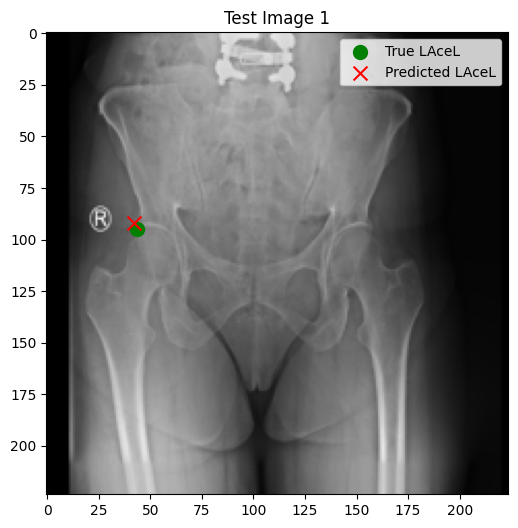

2.9002249043782555 -1.6400956827799433


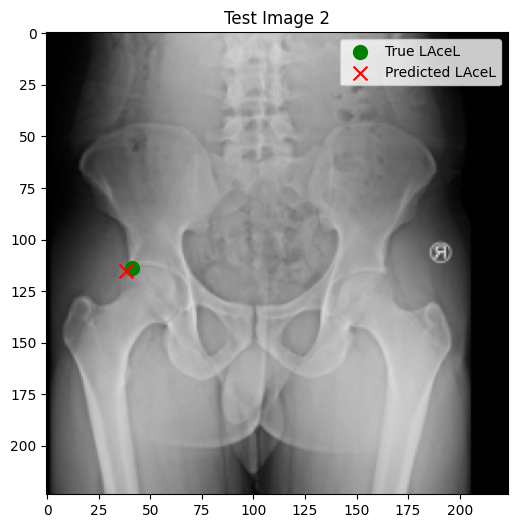

0.6873655497233102 -1.521182779947921


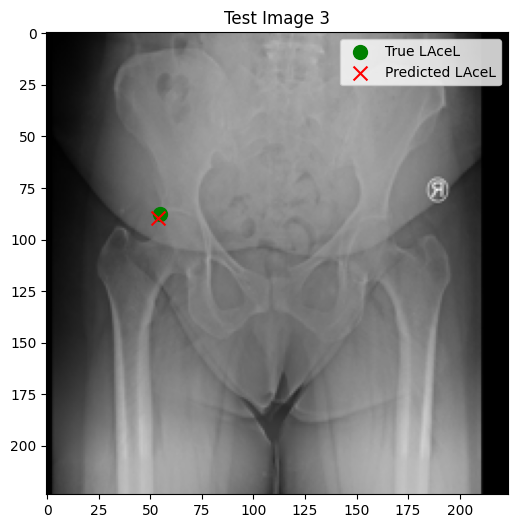

-1.266162811279294 0.17123708089192746


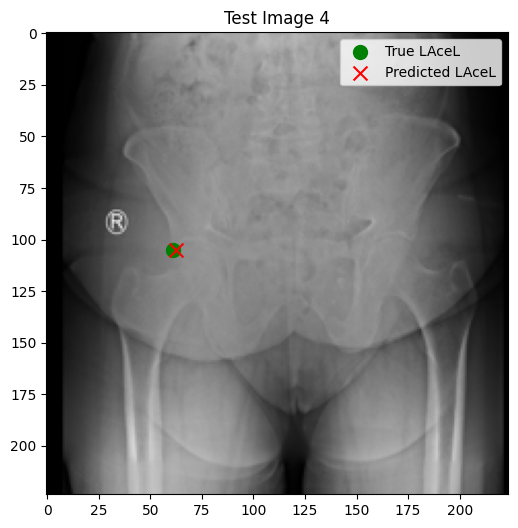

3.249672037760419 2.0146177368164047


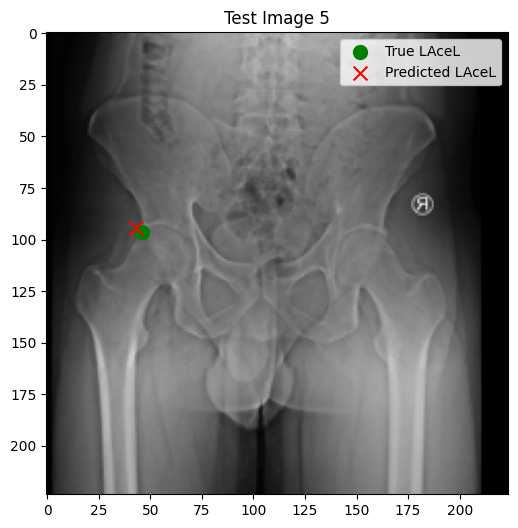

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_mae = model.evaluate(test_images, test_landmarks_first)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

# Make predictions on the test dataset
predictions = model.predict(test_images)

# Visualize the results
import matplotlib.pyplot as plt

# Define a marker and color for the first landmark
marker_true = 'o'
marker_pred = 'x'
color_true = 'green'
color_pred = 'red'

# Number of test images to visualize
num_visualize = 5

# Plot the test images with true and predicted landmarks
for i in range(num_visualize):
    plt.figure(figsize=(6, 6))
    plt.imshow(test_images[i])

    # True landmark
    true_landmark = test_landmarks_first[i]
    plt.scatter(true_landmark[0], true_landmark[1], color=color_true, label='True LAceL', s=100, marker=marker_true)

    # Predicted landmark
    predicted_landmark = predictions[i]
    plt.scatter(predicted_landmark[0], predicted_landmark[1], color=color_pred, label='Predicted LAceL', s=100, marker=marker_pred)
    print(true_landmark[0]-predicted_landmark[0], true_landmark[1]-predicted_landmark[1])
    plt.title(f"Test Image {i+1}")
    plt.legend()
    plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first700.h5')

# Evaluate the model on the test dataset
test_loss, test_mae = model.evaluate(test_images, test_landmarks[:, :2])

# Make predictions on the test dataset
predictions = model.predict(test_images)

# Extract only the first landmark coordinates (LAceL-x and LAceL-y) for the test set
test_landmarks_first = test_landmarks[:, :2]

# Combine the data into a DataFrame
data = {
    'Name': [f'image_{i}' for i in range(len(test_images))],  # Replace this with the actual image names if available
    'Predicted_X': predictions[:, 0],
    'Predicted_Y': predictions[:, 1],
    'Original_X': test_landmarks_first[:, 0],
    'Original_Y': test_landmarks_first[:, 1],
    'Euclidean_Distance': np.sqrt((predictions[:, 0] - test_landmarks_first[:, 0])**2 + (predictions[:, 1] - test_landmarks_first[:, 1])**2)
}

df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
csv_path = '/content/drive/MyDrive/Hip2/csv/Part1_LAceL1.csv'
df.to_csv(csv_path, index=False)

print(f"CSV file saved to {csv_path}")


4/4 [==============================] - 2s 96ms/step
CSV file saved to /content/drive/MyDrive/Hip2/csv/Part1_LAceL1.csv


In [ ]:
import tensorflow as tf
import numpy as np

# Load the trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first700.h5')

# Extract only the first landmark coordinates (LAceL-x and LAceL-y) for the test set
test_landmarks_first = test_landmarks[:, :2]

print("Model and datasets loaded successfully.")


Model and datasets loaded successfully.


In [ ]:
# Predict landmarks on the test dataset
predicted_landmarks_first = model.predict(test_images)

# Calculate the errors in each direction
errors = test_landmarks_first - predicted_landmarks_first
errors_x = errors[:, 0]
errors_y = errors[:, 1]

# Find the maximum errors in each direction
max_error_x = np.max(np.abs(errors_x))
max_error_y = np.max(np.abs(errors_y))

print(f"Maximum error in x direction: {max_error_x}")
print(f"Maximum error in y direction: {max_error_y}")


4/4 [==============================] - 1s 102ms/step
Maximum error in x direction: 8.880375417073566
Maximum error in y direction: 9.132934631347652


#Part 2


##save

In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Load the trained model
model_path = '/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first700.h5'
model = load_model(model_path)

# Define paths
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'

# Read the Excel file into a DataFrame
df = pd.read_excel(file_path)

# Select specific columns
columns_of_interest = ["Height", "Width", "Name", "LAceL-x", "LAceL-y"]
df_selected = df[columns_of_interest]

# Initialize lists to hold processed images and landmarks
high_quality_images = []
predicted_landmarks = []
original_landmarks = []
transformation_details = []
crop_size=224*2
# Process each image
for index, row in df_selected.iterrows():
    img_name = row['Name']
    img_path = os.path.join(image_dir, f"{img_name}.png")

    # Load the high-quality image
    img = Image.open(img_path)
    img=img.resize((3000,3000))
    orig_width, orig_height = img.size

    # Resize the image to 224x224 for model prediction
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)

    # Predict the landmark on the resized image
    pred_landmark = model.predict(np.expand_dims(img_array, axis=0))[0]

    # Transform the predicted landmark to the original image coordinates
    pred_landmark_orig_x = pred_landmark[0] * orig_width / 224
    pred_landmark_orig_y = pred_landmark[1] * orig_height / 224

    # Crop a 700x700 patch around the predicted landmark
    crop_x = int(pred_landmark_orig_x - crop_size/2)
    crop_y = int(pred_landmark_orig_y -  crop_size/2)

    crop_x = max(0, min(crop_x, orig_width - crop_size))
    crop_y = max(0, min(crop_y, orig_height - crop_size))

    img_cropped = img.crop((crop_x, crop_y, crop_x + crop_size, crop_y + crop_size))

    # Resize the cropped image to 224x224
    img_cropped_resized = img_cropped.resize((224, 224))

    # Transform the original landmark to the new cropped and resized image coordinates
    real_landmark_x = (row['LAceL-x'] - crop_x) * 224 / crop_size
    real_landmark_y = (row['LAceL-y'] - crop_y) * 224 / crop_size

    # Convert the cropped and resized image to numpy array
    img_cropped_array = np.array(img_cropped_resized)

    # Append to lists
    high_quality_images.append(img_cropped_array)
    predicted_landmarks.append([pred_landmark_orig_x, pred_landmark_orig_y])
    original_landmarks.append([real_landmark_x, real_landmark_y])
    transformation_details.append([img_name, crop_x, crop_y, orig_width, orig_height])

# Convert lists to numpy arrays
high_quality_images = np.array(high_quality_images)
predicted_landmarks = np.array(predicted_landmarks)
original_landmarks = np.array(original_landmarks)
transformation_details = pd.DataFrame(transformation_details, columns=['Name', 'CropX', 'CropY', 'OrigWidth', 'OrigHeight'])

# Save the transformation details to a CSV file
transformation_details.to_csv('/content/drive/MyDrive/Hip2/transformation_details.csv', index=False)

print(f"Processed {len(high_quality_images)} high-quality images.")


In [ ]:
import numpy as np
import pandas as pd

# Define paths
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'
test_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/test_index.npy'
train_val_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/train_validation_index.npy'

# Read the indices
test_indices = np.load(test_index_path)
train_val_indices = np.load(train_val_index_path)

# Split the dataset using provided indices
train_val_images = high_quality_images[train_val_indices]
train_val_landmarks = original_landmarks[train_val_indices]
test_images = high_quality_images[test_indices]
test_landmarks = original_landmarks[test_indices]

# Further split the train_val set into training and validation sets
from sklearn.model_selection import train_test_split

train_images, val_images, train_landmarks, val_landmarks = train_test_split(
    train_val_images, train_val_landmarks, test_size=0.2, random_state=42
)

print(f"Training set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")

# Save the datasets
np.save('/content/drive/MyDrive/Hip2/Data/train_images_cropped1.npy', train_images)
np.save('/content/drive/MyDrive/Hip2/Data/train_landmarks_cropped1.npy', train_landmarks)
np.save('/content/drive/MyDrive/Hip2/Data/val_images_cropped1.npy', val_images)
np.save('/content/drive/MyDrive/Hip2/Data/val_landmarks_cropped1.npy', val_landmarks)
np.save('/content/drive/MyDrive/Hip2/Data/test_images_cropped1.npy', test_images)
np.save('/content/drive/MyDrive/Hip2/Data/test_landmarks_cropped1.npy', test_landmarks)


##train

In [ ]:
import numpy as np
# Load the cropped datasets
train_images = np.load('/content/drive/MyDrive/Hip2/Data/train_images_cropped1.npy')
train_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/train_landmarks_cropped1.npy')
val_images = np.load('/content/drive/MyDrive/Hip2/Data/val_images_cropped1.npy')
val_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/val_landmarks_cropped1.npy')
test_images = np.load('/content/drive/MyDrive/Hip2/Data/test_images_cropped1.npy')
test_landmarks = np.load('/content/drive/MyDrive/Hip2/Data/test_landmarks_cropped1.npy')

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the ResNet50 model with pretrained weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add global average pooling layer
x = GlobalAveragePooling2D()(base_model.output)

# Add a fully connected layer with 256 units and ReLU activation
x = Dense(256, activation='relu')(x)
# Add a dropout layer
x = Dropout(0.2)(x)

# Add a fully connected layer with 64 units and ReLU activation
x = Dense(64, activation='relu')(x)

# Add another dropout layer
x = Dropout(0.1)(x)

# Add a fully connected layer with 8 units and ReLU activation
x = Dense(8, activation='relu')(x)

# Add the output layer with 2 units (for the landmark's x and y coordinates)
output = Dense(2, activation='linear')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=output)

# Function to freeze the first n layers
def freeze_layers(model, n):
    """Freeze the first n layers of the model."""
    for i, layer in enumerate(model.layers):
        layer.trainable = i >= n

# Specify how many layers you want to freeze
n_freeze =140
freeze_layers(base_model, n_freeze)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=euclidean_distance,
              metrics=[euclidean_distance])

# Print the model summary to check which layers are trainable
model.summary()


Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_14 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_14[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the custom Euclidean distance metric
def euclidean_distance(y_true, y_pred):
    return K.sqrt(K.sum(K.square(y_pred - y_true), axis=-1))

# Define the checkpoint path
checkpoint_path = '/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first_part2.h5'

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_euclidean_distance', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_euclidean_distance', patience=40, restore_best_weights=True)

# Compile the model with the custom metric
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=euclidean_distance,
              metrics=['mae', euclidean_distance])

# Train the model
history = model.fit(
    train_images, train_landmarks,
    validation_data=(val_images, val_landmarks),
    epochs=400,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)

# Evaluate the model on the test dataset
test_loss, test_mae, test_euclidean_distance = model.evaluate(test_images, test_landmarks)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}, Test Euclidean Distance: {test_euclidean_distance}")


Epoch 1/400
37/37 [==============================] - 20s 295ms/step - loss: 138.2731 - mae: 97.3463 - euclidean_distance: 138.2731 - val_loss: 338.1774 - val_mae: 234.4358 - val_euclidean_distance: 338.1774
Epoch 2/400
37/37 [==============================] - 4s 122ms/step - loss: 45.3767 - mae: 30.5571 - euclidean_distance: 45.3767 - val_loss: 103.1679 - val_mae: 71.6901 - val_euclidean_distance: 103.1679
Epoch 3/400
37/37 [==============================] - 6s 164ms/step - loss: 23.1710 - mae: 14.8290 - euclidean_distance: 23.1710 - val_loss: 27.0437 - val_mae: 17.0310 - val_euclidean_distance: 27.0437
Epoch 4/400
37/37 [==============================] - 3s 86ms/step - loss: 21.5132 - mae: 13.8436 - euclidean_distance: 21.5132 - val_loss: 33.6584 - val_mae: 21.4448 - val_euclidean_distance: 33.6584
Epoch 5/400
37/37 [==============================] - 3s 85ms/step - loss: 21.3449 - mae: 13.7657 - euclidean_distance: 21.3449 - val_loss: 40.0239 - val_mae: 25.9055 - val_euclidean_distanc

In [ ]:
#checkpoint_path = '/content/drive/MyDrive/HIP/resnet50_landmarks_600.h5'
#checkpoint_path = '/content/drive/MyDrive/HIP/resnet50_landmarks_601.h5'
#checkpoint_path = '/content/drive/MyDrive/HIP/resnet50_landmarks_602.h5'
#checkpoint_path = '/content/drive/MyDrive/HIP/resnet50_landmarks_602.h5'
#checkpoint_path = '/content/drive/MyDrive/HIP/resnet50_landmarks_611.h5'
#checkpoint_path = '/content/drive/MyDrive/Hip2/Models/resnet50_landmarks_first_part2.h5'

##result

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the custom Euclidean distance metric
def euclidean_distance(y_true, y_pred):
    return K.sqrt(K.sum(K.square(y_pred - y_true), axis=-1))
# Evaluate the model on the test dataset
test_loss, test_mae, test_euclidean_distance = model.evaluate(test_images, test_landmarks)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}, Test Euclidean Distance: {test_euclidean_distance/224*(crop_size/10)}",'mm')


4/4 [==============================] - 0s 96ms/step - loss: 8.4939 - mae: 5.3440 - euclidean_distance: 8.4939
Test Loss: 8.49386215209961, Test MAE: 5.3439788818359375, Test Euclidean Distance: 1.6987724304199219 mm


In [ ]:
import numpy as np
import pandas as pd
import math
# Define paths
file_path = '/content/drive/MyDrive/HIP/data/HighQuality/NewFilePaths.xlsx'
image_dir = '/content/drive/MyDrive/HIP/data/HighQuality/'
test_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/test_index.npy'
train_val_index_path = '/content/drive/MyDrive/HIP/data/HighQuality/train_validation_index.npy'

# Read the indices
test_indices = np.load(test_index_path)

# Load the datasets
# Define the path to the CSV file
csv_path = '/content/drive/MyDrive/Hip2/csv/test_dataset.csv'

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(csv_path)

# Adjust the column names as needed
landmark_columns = ['LAceL-x', 'LAceL-y']

# Extract the landmark data from the DataFrame
test_landmarks = df[landmark_columns].values

# Convert the extracted data to a NumPy array
test_landmarks_org = np.array(test_landmarks)

# Load the transformation details for the test set
transformation_details = pd.read_csv('/content/drive/MyDrive/Hip2/transformation_details.csv')

# Filter transformation details for the test set using test indices
test_transformation_details = transformation_details.iloc[test_indices]

# Predict landmarks on the test dataset
predicted_landmarks = model.predict(test_images)

# Initialize lists to hold the results
results = []

# Iterate over each image in the test set
for i in range(len(test_images)):
    # Get transformation details for the current image
    row = test_transformation_details.iloc[i]
    img_name = row['Name']
    crop_x = row['CropX']
    crop_y = row['CropY']
    orig_width = row['OrigWidth']
    orig_height = row['OrigHeight']

    # Get the predicted landmark coordinates
    pred_x, pred_y = predicted_landmarks[i]

    # Transform the predicted landmark to the original image coordinates
    pred_x_orig = (pred_x * crop_size / 224) + crop_x
    pred_y_orig = (pred_y * crop_size / 224) + crop_y

    # Get the original landmark coordinates
    original_x = test_landmarks_org[i][0]
    original_y = test_landmarks_org[i][1]

    # Calculate the Euclidean distance (MAE) for this image
    euclidean_distance = math.sqrt((pred_x_orig - original_x)**2 + (pred_y_orig - original_y)**2)

    # Append the results to the list
    results.append([img_name, pred_x_orig, pred_y_orig, original_x, original_y, euclidean_distance])

# Convert the results to a DataFrame
results_df = pd.DataFrame(results, columns=['Name', 'Predicted_X_Original', 'Predicted_Y_Original', 'Original_X', 'Original_Y', 'Euclidean_Distance'])

# Save the results to a CSV file
results_df.to_csv('/content/drive/MyDrive/Hip2/Result/test_predictions_and_mae1.csv', index=False)


4/4 [==============================] - 1s 104ms/step


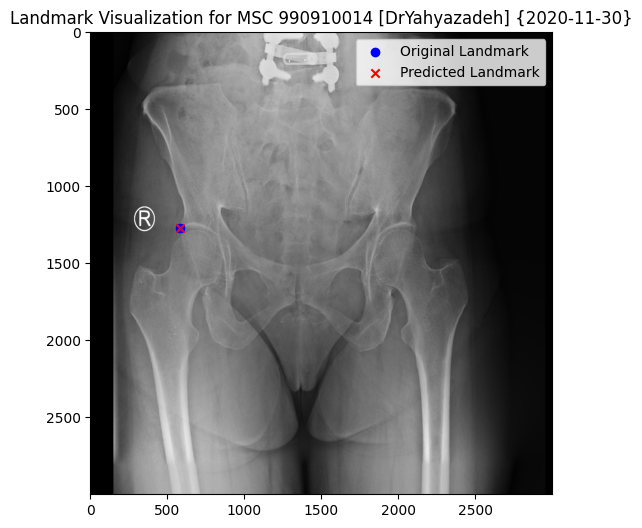

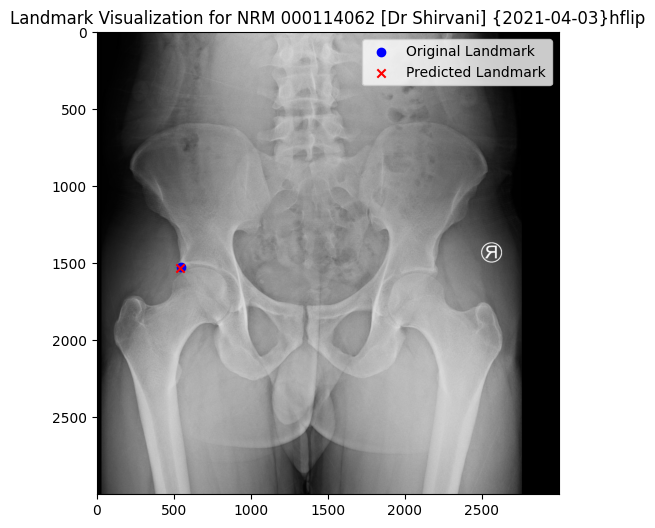

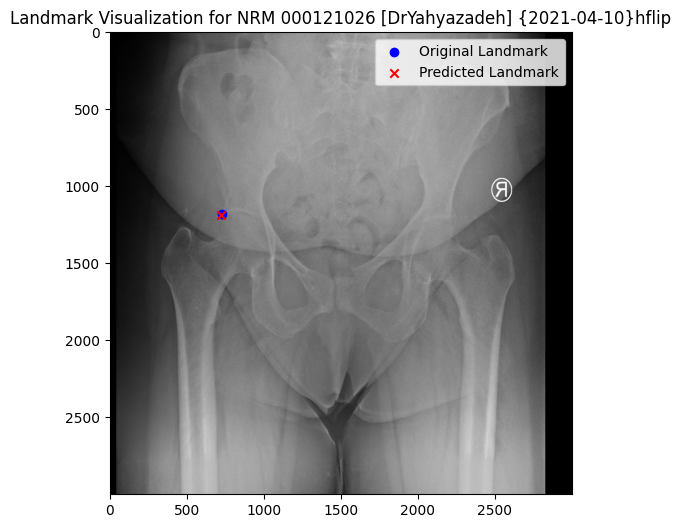

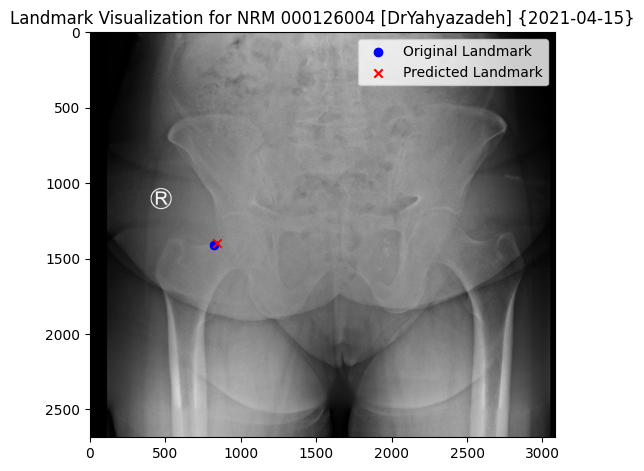

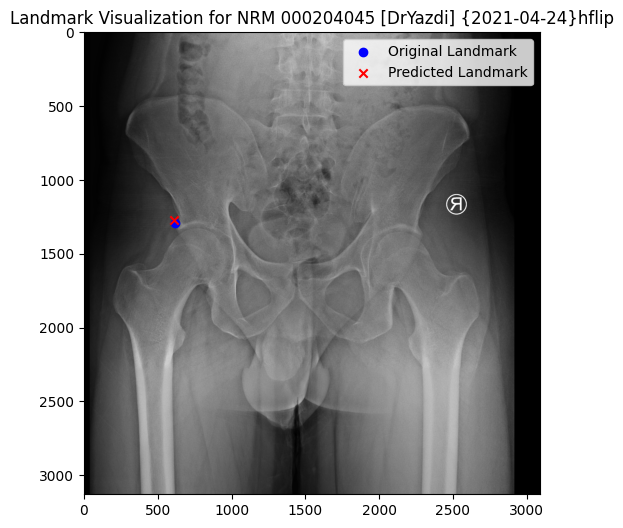

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to the CSV file and image directory
csv_path = '/content/drive/MyDrive/Hip2/Result/test_predictions_and_mae1.csv'
image_dir = '/content/drive/MyDrive/Hip2/original_test_images/'

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(csv_path)

# Select the first 5 entries
df_selected = df.head(5)

# Loop through the selected entries
for index, row in df_selected.iterrows():
    img_name = row['Name']
    img_path = os.path.join(image_dir, f"{img_name}.png")

    # Load the image
    img = Image.open(img_path)

    # Get the landmarks
    pred_x = row['Predicted_X_Original']
    pred_y = row['Predicted_Y_Original']
    orig_x = row['Original_X']
    orig_y = row['Original_Y']

    # Plot the image and the landmarks
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.scatter([orig_x], [orig_y], c='blue', marker='o', label='Original Landmark')
    plt.scatter([pred_x], [pred_y], c='red', marker='x', label='Predicted Landmark')
    plt.legend()
    plt.title(f'Landmark Visualization for {img_name}')
    plt.show()
